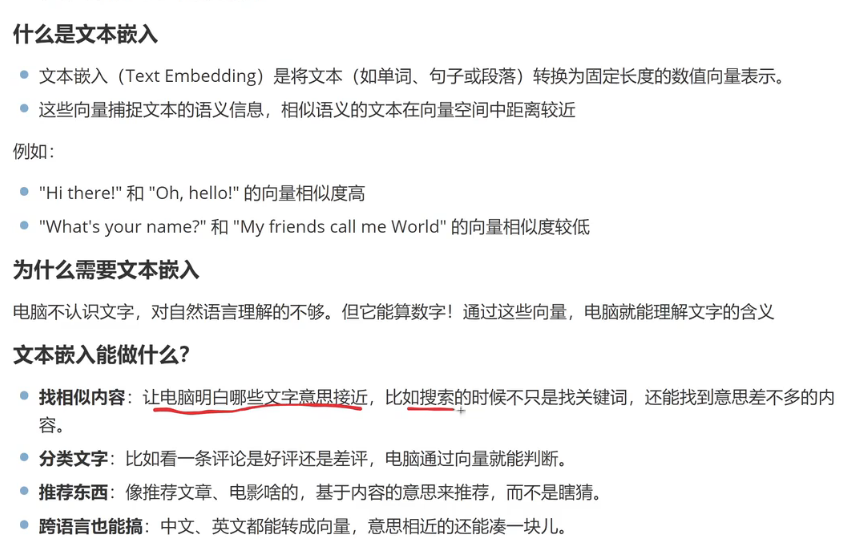  

In [1]:
import os
from langchain_community.chat_models import ChatZhipuAI
zhipuai_api_key = "4c436c37955741c290d3b97fce80fbb9.R6C2peSTtc9Stc8N"
os.environ["ZHIPUAI_API_KEY"] = zhipuai_api_key     

chat = ChatZhipuAI(
    model="glm-4",
    temperature=0.5,
)

C:\Users\86131\AppData\Local\Temp\ipykernel_14584\258078160.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.chat_models import ChatZhipuAI
d:\Anaconda\envs\agent_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 网络版文本嵌入  

In [3]:
from langchain_community.embeddings import ZhipuAIEmbeddings
embeddings = ZhipuAIEmbeddings(model="embedding-2")

comments = ['这个产品太棒了', '垃圾产品，差评', '质量不错，值得购买', '非常失望，不推荐']
vectors = embeddings.embed_documents(comments)
print(vectors)
print(len(vectors[0]))
print(vectors[0])

[[-0.0324889, 0.028152574, -0.0037833632, 0.07919103, 0.03818164, -0.024106234, -0.0072950246, -0.028541714, -0.02617763, 0.03176201, -0.025387, 0.008114318, -0.0003132422, -0.01109073, -0.012192504, 0.03712515, -0.005652089, -0.022673698, 0.039590243, -0.010550972, -0.022593237, -0.017888855, -0.033024803, -0.045208044, -0.02762416, 0.014879352, -0.009396767, -0.015841164, 0.023988385, -0.019954365, 0.0061420044, -0.006716515, 0.00921454, -0.021041203, 0.019881906, 0.021505324, 0.022499798, 0.030945273, -0.0075689536, -0.042526104, 0.0028336558, -0.020412898, 0.01329007, -0.035863582, -0.0016425484, -0.03107368, 0.031110894, 0.092841625, -0.013480562, 0.035916634, 0.006705325, 0.014366981, -0.031125704, -0.0043802606, 0.03899668, -0.0036901038, 0.06441064, 0.010521743, -0.015547779, 0.040179875, -0.011209757, 0.051058292, -0.011704216, 0.043816987, -0.007115276, -0.0065389965, 0.002287449, -0.016162373, -0.005774319, -0.023192193, -0.035383593, -0.053105064, -0.018405762, 0.004367163,

In [6]:
test_commit = ["这个产品超好用"]
test_vector = embeddings.embed_documents(test_commit)
print(test_vector)

[[-0.024256466, 0.02299622, -0.04025469, 0.055844203, 0.01976528, -0.03225315, 0.011908498, -0.020231158, -0.02262483, 0.052494977, -0.04761467, 0.035578642, -0.0029948265, 0.009426587, -0.02182096, 0.03357844, -0.01074165, -0.017379876, 0.014798057, 0.027336242, -0.0060149683, 0.0062311557, -0.03828415, -0.044534083, -0.01565911, 0.01363287, 0.007013032, -0.02802288, 0.019988414, -0.031010171, 0.0066871066, 0.008880482, 0.023575507, 0.0005987774, -0.0009945864, 0.005120431, 0.014918974, 0.019292131, 0.0007785588, -0.039574314, 0.015466394, -0.011337677, -0.014009968, -0.011895846, -0.0069390517, -0.053386327, 0.03420319, 0.07965588, 0.023704775, 0.054384608, 0.015920632, -0.0031742097, -0.009043122, 0.013229145, 0.022108648, 0.03716863, 0.045943238, -0.019173272, -0.024465702, 0.034294676, -0.014805767, 0.03624093, -0.005611864, 0.035710335, -0.011124109, 0.0032035941, 0.036248073, -0.016428985, 0.0015025897, -0.036061842, -0.037082028, -0.013079418, -0.035909735, 0.002180335, 0.04468

In [12]:
from sklearn.linear_model import LogisticRegression

labels = [1, 0, 1, 0]  # 1表示正面评价，0表示负面评价s
model = LogisticRegression()
model.fit(vectors, labels)
prediction = model.predict(test_vector)
print(prediction[0])

1


## 本地模型embeddding

In [5]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="bge-small-zh-v1.5",
                                   model_kwargs={"device": "cpu"}
)
comments = ['这个产品太棒了', '垃圾产品，差评', '质量不错，值得购买', '非常失望，不推荐']
vectors = embeddings.embed_documents(comments)

query = "这个产品怎么样？"
query_vector = embeddings.embed_query(query)
print(query_vector)
print(len(query_vector))
print(vectors)

Loading weights: 100%|██████████| 71/71 [00:00<00:00, 5199.76it/s]

[-0.022680038586258888, 0.000445853074779734, -0.016627740114927292, 0.020384136587381363, 0.02800457365810871, -0.021748902276158333, 0.030201906338334084, 0.07200145721435547, 0.055289704352617264, 0.03955904394388199, 0.07977631688117981, -0.27816832065582275, 0.014017191715538502, -0.060505159199237823, -0.06384700536727905, 0.03740623593330383, -0.06864935159683228, -0.0024269181303679943, -0.013640429824590683, -0.005722165107727051, 0.02269863337278366, -0.03669881075620651, -0.07106306403875351, 0.0891999751329422, -0.0072339316830039024, 0.08170992136001587, -0.011837003752589226, 0.02426290698349476, -0.033583514392375946, -0.0339902900159359, 0.01712728478014469, -0.0018368370365351439, 0.02225075475871563, -0.053165875375270844, 0.002990971552208066, -0.021595565602183342, 0.012437772005796432, 0.02699369378387928, -0.012670333497226238, -0.04125312715768814, 0.029226727783679962, -0.010501340962946415, -0.05795982480049133, 0.009852185845375061, 0.03127390518784523, 0.0056

## 练习  

In [37]:
from langchain_community.document_loaders import TextLoader
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
#中文分块
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=20,
                                               separators=["\n\n", "\n", "!", "。", "？", ".", "！", "?", ",", "，", " ", ""])
#加载文件
loader = TextLoader("./政策文件.txt")
res = loader.load_and_split(text_splitter)
split_docs = text_splitter.split_documents(loader.load())
print(len(split_docs))
i=1
for doc in split_docs:
    print(f"这是分块{i}, 内容是{doc.page_content}")
    i=i+1


2
这是分块1, 内容是公司年假政策：
1. 员工工作满1年可享受5天带薪年假
2. 年假有效期至次年3月31日
3. 部门经理审批后方可使用
这是分块2, 内容是考勤制度：
- 工作日上班时间：9:00-18:00
- 迟到超过30分钟记为缺勤


In [8]:
# 数据持久化
from langchain_community.document_loaders import TextLoader
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
#中文分块
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=20,
                                               separators=["\n\n", "\n", "!", "。", "？", ".", "！", "?", ",", "，", " ", ""])
#加载文件
loader = TextLoader("./政策文件.txt")
split_docs = text_splitter.split_documents(loader.load())

embeddings = HuggingFaceEmbeddings(model_name="bge-small-zh-v1.5",
                                   model_kwargs={"device": "cpu"}
)

db = Chroma.from_documents(
    documents=split_docs,
    embedding=embeddings,
    persist_directory="./chroma_db"
)
docs = db.similarity_search("迟到处罚",k=1)
print(docs)
for doc in docs:
    print(doc.page_content)

Loading weights: 100%|██████████| 71/71 [00:00<00:00, 4931.45it/s]


[Document(metadata={'source': './政策文件.txt'}, page_content='考勤制度：\n- 工作日上班时间：9:00-18:00\n- 迟到超过30分钟记为缺勤')]
考勤制度：
- 工作日上班时间：9:00-18:00
- 迟到超过30分钟记为缺勤
